In [ ]:
import pandas as pd
import numpy as np
from chronos import Chronos2Pipeline

pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

# --- Synthetic data replacing S3 download ---
np.random.seed(42)
n_series = 3
context_length = 168  # 1 week of hourly data
prediction_length = 24

ids = [f"series_{i}" for i in range(n_series)]
timestamps = pd.date_range("2024-01-01", periods=context_length, freq="h")

# Build context_df with a synthetic covariate
context_rows = []
for sid in ids:
    target = 50 + 10 * np.sin(np.linspace(0, 4 * np.pi, context_length)) + np.random.randn(context_length) * 2
    covariate = np.random.randn(context_length)
    for t, ts in enumerate(timestamps):
        context_rows.append({"id": sid, "timestamp": ts, "target": target[t], "covariate": covariate[t]})

context_df = pd.DataFrame(context_rows)

# Build future_df (covariates only, no target)
future_timestamps = pd.date_range(timestamps[-1] + pd.Timedelta(hours=1), periods=prediction_length, freq="h")
future_rows = []
for sid in ids:
    for ts in future_timestamps:
        future_rows.append({"id": sid, "timestamp": ts, "covariate": np.random.randn()})

future_df = pd.DataFrame(future_rows)
# --- End synthetic data ---

# Generate predictions with covariates
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)

print(pred_df.head())

In [2]:
import pandas as pd
import numpy as np
from chronos import Chronos2Pipeline

pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

# --- Minimal synthetic data ---
ids = ["series_0"]
timestamps = pd.date_range("2024-01-01", periods=48, freq="h")  # 2 days

context_df = pd.DataFrame({
    "id": "series_0",
    "timestamp": timestamps,
    "target": np.random.randn(48),
    "covariate": np.random.randn(48),
})

future_timestamps = pd.date_range(timestamps[-1] + pd.Timedelta(hours=1), periods=24, freq="h")
future_df = pd.DataFrame({
    "id": "series_0",
    "timestamp": future_timestamps,
    "covariate": np.random.randn(24),
})
# --- End synthetic data ---

pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=24,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)

print(pred_df.head())

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

         id           timestamp target_name  predictions       0.1       0.5  \
0  series_0 2024-01-03 00:00:00      target     0.574859 -0.728133  0.574859   
1  series_0 2024-01-03 01:00:00      target     0.529667 -0.821091  0.529667   
2  series_0 2024-01-03 02:00:00      target     0.514605 -0.863334  0.514605   
3  series_0 2024-01-03 03:00:00      target     0.536204 -0.850975  0.536204   
4  series_0 2024-01-03 04:00:00      target     0.490740 -0.876371  0.490740   

        0.9  
0  1.824879  
1  1.833204  
2  1.804402  
3  1.830222  
4  1.818789  


In [1]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No CUDA device found — use device_map='cpu'")

CUDA available: True
Device: Tesla T4
VRAM: 15.7 GB


In [3]:
import torch
from transformers import TimesFm2_5ModelForPrediction

model = TimesFm2_5ModelForPrediction.from_pretrained("google/timesfm-2.5-200m-transformers")
model = model.to(torch.float32).eval()

past_values = [
    torch.linspace(0, 1, 100),
    torch.sin(torch.linspace(0, 20, 67)),
]

with torch.no_grad():
    outputs = model(past_values=past_values, forecast_context_len=1024)

print(outputs.mean_predictions.shape)
print(outputs.full_predictions.shape)


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

torch.Size([2, 128])
torch.Size([2, 128, 10])


In [3]:
import pandas as pd
import numpy as np

# ── 1. Load ──────────────────────────────────────────────────────────────────
df = pd.read_csv("banks_monthly_m4.csv")

# ── 2. Normalise column names ─────────────────────────────────────────────────
df.columns = df.columns.str.strip()

# Rename for convenience
df = df.rename(columns={
    "Calendar Year/Année civile":                          "calendar_year",
    "Calendar Month/Mois civil":                           "calendar_month",
    "Id":                                                  "fi_id",
    "Data Point Address/Adresse de point de donnée":       "code",
    "Measure Value/Valeur de mesure":                      "value",
    "Data Point Address Label":                            "code_label",
})

# ── 3. Filter to CIBC (FI ID 27996) ──────────────────────────────────────────
cibc = df[df["fi_id"] == 27996].copy()

# ── 4. Keep only TOTAL-currency rows ─────────────────────────────────────────
# The label column contains "total" for total-currency rows
# and "foreign currency" for FX-only rows — drop the FX rows to avoid double-counting
cibc = cibc[
    cibc["code_label"].str.lower().str.contains("total") &
    ~cibc["code_label"].str.lower().str.contains("foreign currency")
]

# ── 5. Cast types ─────────────────────────────────────────────────────────────
cibc["calendar_month"] = pd.to_datetime(cibc["calendar_month"])
cibc["code"]           = cibc["code"].astype(int)
cibc["value"]          = pd.to_numeric(cibc["value"], errors="coerce").fillna(0)

# ── 6. Define deposit code buckets ───────────────────────────────────────────
DEMAND_NOTICE_CODES = [873, 874, 875, 876, 877, 878]
FIXED_TERM_CODES    = [616, 618, 880, 881, 2202, 2339]

# ── 7. Helper: sum a code list for a given month group ───────────────────────
def sum_codes(group, codes):
    return group.loc[group["code"].isin(codes), "value"].sum()

# ── 8. Monthly aggregation ────────────────────────────────────────────────────
records = []

for month, grp in cibc.groupby("calendar_month"):
    demand_notice = sum_codes(grp, DEMAND_NOTICE_CODES) / 1_000   # convert to $B
    fixed_term    = sum_codes(grp, FIXED_TERM_CODES)    / 1_000
    total_deps    = demand_notice + fixed_term

    records.append({
        "month":                    month,
        "demand_notice_deposits_B": round(demand_notice, 3),
        "fixed_term_deposits_B":    round(fixed_term,    3),
        "total_deposits_B":         round(total_deps,    3),
    })

monthly = pd.DataFrame(records).sort_values("month").reset_index(drop=True)

# ── 9. Completeness flag: all 12 months present per calendar year ─────────────
monthly["calendar_year"]       = monthly["month"].dt.year
months_per_year                = monthly.groupby("calendar_year")["month"].transform("count")
monthly["all_12_months_flag"]  = months_per_year == 12

# ── 10. Clean up column order ─────────────────────────────────────────────────
monthly = monthly[[
    "month",
    "calendar_year",
    "demand_notice_deposits_B",
    "fixed_term_deposits_B",
    "total_deposits_B",
    "all_12_months_flag",
]]

# ── 11. Preview & export ──────────────────────────────────────────────────────
print(monthly.to_string(index=False))
monthly.to_csv("cibc_monthly_deposits.csv", index=False)
print("\n✅ Saved → cibc_monthly_deposits.csv")

     month  calendar_year  demand_notice_deposits_B  fixed_term_deposits_B  total_deposits_B  all_12_months_flag
1996-01-31           1996                     0.000              94442.784         94442.784                True
1996-02-29           1996                     0.000              96952.305         96952.305                True
1996-03-31           1996                     0.000              95433.179         95433.179                True
1996-04-30           1996                     0.000              89325.381         89325.381                True
1996-05-31           1996                     0.000              93360.359         93360.359                True
1996-06-30           1996                     0.000              94354.714         94354.714                True
1996-07-31           1996                     0.000              91802.142         91802.142                True
1996-08-31           1996                     0.000              94580.684         94580.684    

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]


📊 CIBC Total Deposit Forecast (CAD Millions)

                    id  timestamp target_name  predictions         0.1  \
0  CIBC_total_deposits 2026-05-31      target   814317.250  793661.125   
1  CIBC_total_deposits 2026-06-30      target   816548.125  792740.500   
2  CIBC_total_deposits 2026-07-31      target   819155.000  793960.750   

          0.5         0.9  
0  814317.250  835766.000  
1  816548.125  837516.125  
2  819155.000  841243.250  
 timestamp        0.1        0.5        0.9
2026-05-31 793661.125 814317.250 835766.000
2026-06-30 792740.500 816548.125 837516.125
2026-07-31 793960.750 819155.000 841243.250

✅ Saved → cibc_deposit_forecast.csv


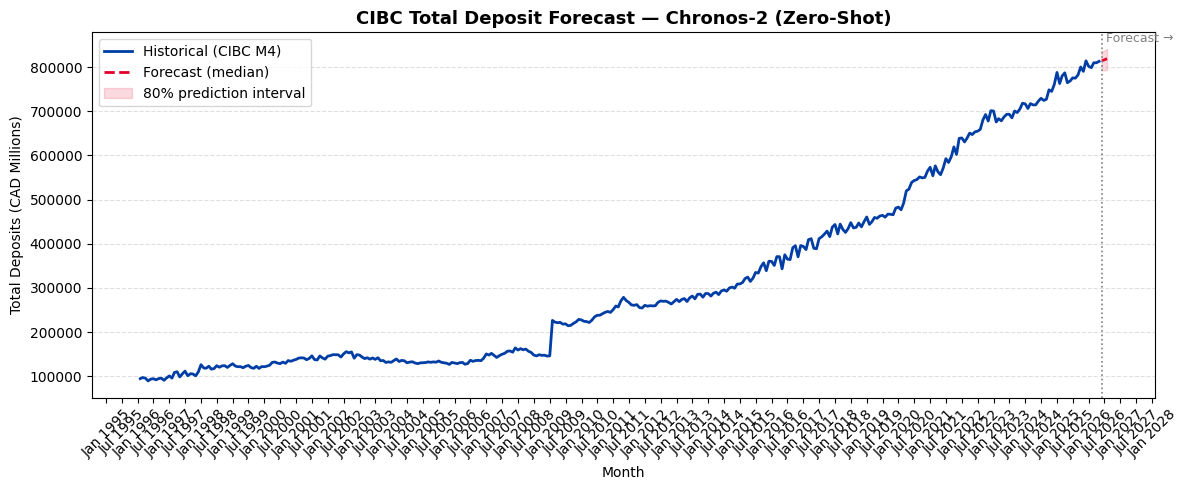

📈 Chart saved → cibc_deposit_forecast.png


In [7]:
# ── Install (run once) ────────────────────────────────────────────────────────
# pip install "chronos-forecasting[torch]" matplotlib pandas

import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from chronos import Chronos2Pipeline

# ── 1. Load aggregated CIBC deposit data ─────────────────────────────────────
monthly = pd.read_csv("cibc_monthly_deposits.csv", parse_dates=["month"])
monthly = monthly.sort_values("month").reset_index(drop=True)

# ── 2. Prepare context DataFrame in Chronos2 format ──────────────────────────
context_df = pd.DataFrame({
    "id":        "CIBC_total_deposits",          # series identifier
    "timestamp": monthly["month"],
    "target":    monthly["total_deposits_B"],    # CAD millions
})

# ── 3. Load Chronos-2 pipeline ───────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device,
)

# ── 4. Generate forecast (12-month horizon) ───────────────────────────────────
FORECAST_MONTHS = 3

pred_df = pipeline.predict_df(
    context_df,
    prediction_length=FORECAST_MONTHS,
    quantile_levels=[0.1, 0.5, 0.9],           # low / median / high
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)

# ── 5. Print results ──────────────────────────────────────────────────────────
print("\n📊 CIBC Total Deposit Forecast (CAD Millions)\n")
print(pred_df)

print(pred_df[["timestamp", "0.1", "0.5", "0.9"]].to_string(index=False))
pred_df.to_csv("cibc_deposit_forecast.csv", index=False)
print("\n✅ Saved → cibc_deposit_forecast.csv")

# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

# Historical
ax.plot(
    context_df["timestamp"], context_df["target"],
    color="#003DA5", linewidth=2, label="Historical (CIBC M4)"
)

# Forecast median
ax.plot(
    pred_df["timestamp"], pred_df["0.5"],
    color="#E4002B", linewidth=2, linestyle="--", label="Forecast (median)"
)

# Confidence band (10th–90th percentile)
ax.fill_between(
    pred_df["timestamp"],
    pred_df["0.1"],
    pred_df["0.9"],
    color="#E4002B", alpha=0.15, label="80% prediction interval"
)

# Divider line at forecast start
forecast_start = pred_df["timestamp"].iloc[0]
ax.axvline(forecast_start, color="grey", linestyle=":", linewidth=1.2)
ax.text(forecast_start, ax.get_ylim()[1], " Forecast →",
        fontsize=9, color="grey", va="top")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

ax.set_title("CIBC Total Deposit Forecast — Chronos-2 (Zero-Shot)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Deposits (CAD Millions)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("cibc_deposit_forecast.png", dpi=150)
plt.show()
print("📈 Chart saved → cibc_deposit_forecast.png")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Original length : 364
Padded length   : 384  (multiple of 32)

📊 CIBC Total Deposit Forecast — TimesFM 2.5 (CAD Millions)

 timestamp  forecast_mean  forecast_q10  forecast_q50  forecast_q90
2026-06-01    812679.1250   785881.8750   810579.0000   834819.8125
2026-07-01    822424.7500   818650.8750   810143.3750   833716.7500
2026-08-01    828560.7500   801970.5000   826317.0000   837606.4375
2026-09-01    834340.6250   812044.8125   824260.7500   851517.3750
2026-10-01    827264.7500   815930.2500   812965.1250   848824.0000
2026-11-01    832409.6875   808235.1875   822542.5000   842814.0000
2026-12-01    842061.2500   811826.3750   836198.1250   847855.8750
2027-01-01    843946.2500   822716.6250   834165.6875   859194.6250
2027-02-01    842425.8750   812931.7500   837352.8125   867466.3750
2027-03-01    848272.6875   828776.9375   842272.1250   876428.1875
2027-04-01    855741.5000   826068.1250   843126.3125   882388.2500
2027-05-01    854651.4375   798237.5000   846282.1875   86337

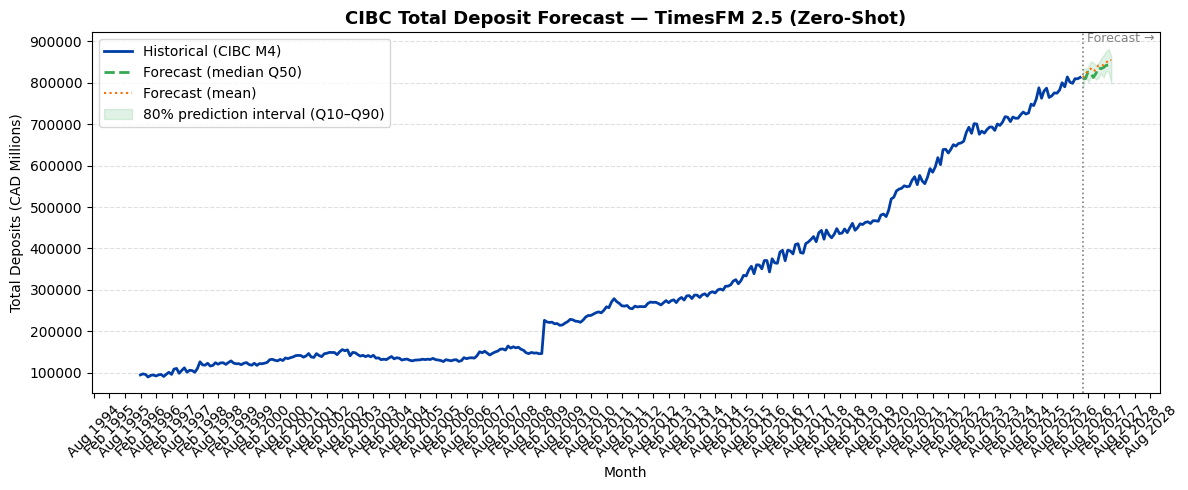

📈 Chart saved → cibc_deposit_forecast_timesfm.png


In [2]:
# ── Install (run once) ────────────────────────────────────────────────────────
# pip install "transformers>=4.51.0" torch matplotlib pandas

import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from transformers import TimesFm2_5ModelForPrediction

# ── 1. Load aggregated CIBC deposit data ──────────────────────────────────────
monthly = pd.read_csv("cibc_monthly_deposits.csv", parse_dates=["month"])
monthly = monthly.sort_values("month").reset_index(drop=True)

target = monthly["total_deposits_B"].values
timestamps = monthly["month"]

# ── 2. Load TimesFM 2.5 model ────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TimesFm2_5ModelForPrediction.from_pretrained(
    "google/timesfm-2.5-200m-transformers"
)
model = model.to(device).to(torch.float32).eval()

# ── 3. Prepare context tensor ────────────────────────────────────────────────
# TimesFM expects a list of 1D tensors (one per series)
FORECAST_MONTHS     = 12
# CONTEXT_LEN         = len(target)          # use full history as context

# context_tensor = torch.tensor(target, dtype=torch.float32).to(device)

# # ── 4. Run inference ──────────────────────────────────────────────────────────
# with torch.no_grad():
#     outputs = model(
#         past_values=[context_tensor],
#         forecast_context_len=CONTEXT_LEN,
#     )

# ── Fix: Pad context to nearest multiple of patch size ────────────────────────
PATCH_SIZE = 32

def pad_to_patch(tensor: torch.Tensor, patch_size: int) -> torch.Tensor:
    length    = tensor.shape[0]
    remainder = length % patch_size
    if remainder == 0:
        return tensor
    pad_len = patch_size - remainder
    # ── Fix: create padding on the same device as the input tensor ──
    padding = torch.full((pad_len,), tensor[0].item(), dtype=tensor.dtype, device=tensor.device)
    return torch.cat([padding, tensor], dim=0)

context_tensor = torch.tensor(target, dtype=torch.float32).to(device)
context_tensor = pad_to_patch(context_tensor, PATCH_SIZE)

CONTEXT_LEN = context_tensor.shape[0]   # now 384 (12 × 32) ✅

print(f"Original length : {len(target)}")
print(f"Padded length   : {CONTEXT_LEN}  (multiple of {PATCH_SIZE})")

# ── Rest of inference is unchanged ────────────────────────────────────────────
with torch.no_grad():
    outputs = model(
        past_values=[context_tensor],
        forecast_context_len=CONTEXT_LEN,
    )

# ── 5. Extract predictions ────────────────────────────────────────────────────
# mean_predictions shape: (batch, prediction_length)
# full_predictions shape: (batch, prediction_length, quantile_levels)
mean_preds = outputs.mean_predictions[0].cpu().numpy()    # (prediction_length,)
full_preds = outputs.full_predictions[0].cpu().numpy()    # (prediction_length, Q)

# Slice to desired horizon
mean_preds = mean_preds[:FORECAST_MONTHS]
full_preds = full_preds[:FORECAST_MONTHS]

# TimesFM default quantiles: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Q10 = full_preds[:, 0]    # 10th percentile
Q50 = full_preds[:, 4]    # 50th percentile (median)
Q90 = full_preds[:, 8]    # 90th percentile

# ── 6. Build forecast date index ──────────────────────────────────────────────
last_date      = timestamps.iloc[-1]
forecast_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=FORECAST_MONTHS,
    freq="MS"
)

# ── 7. Save results ───────────────────────────────────────────────────────────
forecast_df = pd.DataFrame({
    "timestamp":      forecast_dates,
    "forecast_mean":  mean_preds,
    "forecast_q10":   Q10,
    "forecast_q50":   Q50,
    "forecast_q90":   Q90,
})

print("\n📊 CIBC Total Deposit Forecast — TimesFM 2.5 (CAD Millions)\n")
print(forecast_df.to_string(index=False))
forecast_df.to_csv("cibc_deposit_forecast_timesfm.csv", index=False)
print("\n✅ Saved → cibc_deposit_forecast_timesfm.csv")

# ── 8. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

# Historical
ax.plot(
    timestamps, target,
    color="#003DA5", linewidth=2, label="Historical (CIBC M4)"
)

# Forecast median
ax.plot(
    forecast_dates, Q50,
    color="#34A853", linewidth=2, linestyle="--", label="Forecast (median Q50)"
)

# Mean prediction
ax.plot(
    forecast_dates, mean_preds,
    color="#FF6D00", linewidth=1.5, linestyle=":", label="Forecast (mean)"
)

# Confidence band (Q10–Q90)
ax.fill_between(
    forecast_dates, Q10, Q90,
    color="#34A853", alpha=0.15, label="80% prediction interval (Q10–Q90)"
)

# Divider line at forecast start
ax.axvline(forecast_dates[0], color="grey", linestyle=":", linewidth=1.2)
ax.text(forecast_dates[0], ax.get_ylim()[1], " Forecast →",
        fontsize=9, color="grey", va="top")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

ax.set_title("CIBC Total Deposit Forecast — TimesFM 2.5 (Zero-Shot)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Deposits (CAD Millions)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("cibc_deposit_forecast_timesfm.png", dpi=150)
plt.show()
print("📈 Chart saved → cibc_deposit_forecast_timesfm.png")

In [2]:
# ── Install (run once) ────────────────────────────────────────────────────────
# pip install "chronos-forecasting[torch]" matplotlib pandas scikit-learn

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from chronos import Chronos2Pipeline
from sklearn.preprocessing import StandardScaler

# ─────────────────────────────────────────────────────────────────────────────
# 1. LOAD & PREPARE DATA
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv("cibc_monthly_deposits_enriched.csv", parse_dates=["month"])
df = df.sort_values("month").reset_index(drop=True)

TARGET     = "total_deposits_B"
COVARIATES = ["cpi_all_items", "boc_bank_rate", "boc_target_rate"]

# Engineered features (added on top of raw covariates)
df["target_rate_mom_chg"] = df["boc_target_rate"].diff()
df["cpi_mom_chg"]         = df["cpi_all_items"].pct_change() * 100
df["cpi_yoy"]             = df["cpi_all_items"].pct_change(12) * 100
df["rrsp_season"]         = df["month"].dt.month.isin([1, 2]).astype(float)
df["tax_season"]          = df["month"].dt.month.isin([4, 5]).astype(float)
df = df.dropna().reset_index(drop=True)   # drop NaNs from diff/pct_change

ALL_COVARIATES = COVARIATES + [
    "target_rate_mom_chg", "cpi_mom_chg", "cpi_yoy",
    "rrsp_season", "tax_season"
]

# ─────────────────────────────────────────────────────────────────────────────
# 2. SCALE COVARIATES  (Chronos2 ingests raw values; scaling improves stability)
# ─────────────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
cov_scaled = scaler.fit_transform(df[ALL_COVARIATES].values)   # (T, C)

# ─────────────────────────────────────────────────────────────────────────────
# 3. BUILD CONTEXT DATAFRAME  (Chronos2 multivariate format)
#
#    predict_df expects a long-format DataFrame with:
#      - id_column        : series identifier
#      - timestamp_column : datetime
#      - target           : the series to forecast (total deposits)
#      - covariate cols   : additional numeric columns used as past covariates
# ─────────────────────────────────────────────────────────────────────────────
context_df = pd.DataFrame({"timestamp": df["month"], TARGET: df[TARGET].values})

for i, col in enumerate(ALL_COVARIATES):
    context_df[col] = cov_scaled[:, i]

context_df.insert(0, "id", "CIBC")

# ─────────────────────────────────────────────────────────────────────────────
# 4. BUILD FUTURE COVARIATE DATAFRAME
#
#    Chronos2 needs future covariate values for the forecast horizon.
#    For known deterministic features (seasonal flags) we compute them exactly.
#    For macro series (CPI, BoC rate) we forward-fill the last known value
#    as a neutral assumption — replace with BoC projections if available.
# ─────────────────────────────────────────────────────────────────────────────
FORECAST_MONTHS = 12
last_date       = df["month"].iloc[-1]
future_dates    = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=FORECAST_MONTHS, freq="MS"
)

# Last known raw values for macro series
last_raw = df[ALL_COVARIATES].iloc[-1].copy()

future_raw = pd.DataFrame([last_raw.values] * FORECAST_MONTHS, columns=ALL_COVARIATES)

# Override deterministic seasonal features
future_raw["rrsp_season"] = future_dates.month.isin([1, 2]).astype(float).values
future_raw["tax_season"]  = future_dates.month.isin([4, 5]).astype(float).values

# Scale future covariates using the same scaler fitted on history
future_scaled = scaler.transform(future_raw.values)

future_df = pd.DataFrame({"id": "CIBC", "timestamp": future_dates})
for i, col in enumerate(ALL_COVARIATES):
    future_df[col] = future_scaled[:, i]

# ─────────────────────────────────────────────────────────────────────────────
# 5. LOAD CHRONOS-2 & FORECAST
# ─────────────────────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device,
)

print("Running multivariate forecast...")
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,                    # pass future covariates
    prediction_length=FORECAST_MONTHS,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target=TARGET,
)

# ─────────────────────────────────────────────────────────────────────────────
# 6. RESULTS
# ─────────────────────────────────────────────────────────────────────────────
q10_col = f"{TARGET}[0.1]"
q50_col = f"{TARGET}[0.5]"
q90_col = f"{TARGET}[0.9]"

print("\n📊 CIBC Total Deposit Forecast — Chronos-2 Multivariate (CAD Millions)\n")
print(pred_df[["timestamp", q10_col, q50_col, q90_col]].to_string(index=False))
pred_df.to_csv("cibc_multivariate_forecast.csv", index=False)
print("\n✅ Saved → cibc_multivariate_forecast.csv")

# ─────────────────────────────────────────────────────────────────────────────
# 7. PLOT
# ─────────────────────────────────────────────────────────────────────────────
# Show last 5 years of history + forecast for readability
plot_history = df[df["month"] >= (last_date - pd.DateOffset(years=5))]

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# ── Top panel: Deposit forecast ───────────────────────────────────────────────
ax = axes[0]
ax.plot(plot_history["month"], plot_history[TARGET],
        color="#003DA5", linewidth=2, label="Historical deposits")
ax.plot(pred_df["timestamp"], pred_df[q50_col],
        color="#E4002B", linewidth=2, linestyle="--", label="Forecast (Q50)")
ax.fill_between(pred_df["timestamp"], pred_df[q10_col], pred_df[q90_col],
                color="#E4002B", alpha=0.15, label="80% prediction interval")
ax.axvline(pred_df["timestamp"].iloc[0], color="grey", linestyle=":", linewidth=1.2)
ax.set_title("CIBC Total Deposit Forecast — Chronos-2 Multivariate", fontsize=12, fontweight="bold")
ax.set_ylabel("Total Deposits (CAD Millions)")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# ── Bottom panel: Covariate context ──────────────────────────────────────────
ax2 = axes[1]
ax2_twin = ax2.twinx()

ax2.plot(plot_history["month"], plot_history["boc_target_rate"],
         color="#34A853", linewidth=1.8, label="BoC Target Rate (%)")
ax2.plot(plot_history["month"], plot_history["boc_bank_rate"],
         color="#FF6D00", linewidth=1.2, linestyle="--", label="BoC Bank Rate (%)")
ax2_twin.plot(plot_history["month"], plot_history["cpi_all_items"],
              color="#9C27B0", linewidth=1.5, linestyle="-.", label="CPI All-Items")

ax2.set_ylabel("Interest Rate (%)", color="#34A853")
ax2_twin.set_ylabel("CPI Index", color="#9C27B0")
ax2.set_title("Covariate Context (last 5 years)", fontsize=11)
ax2.grid(axis="y", linestyle="--", alpha=0.3)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("cibc_multivariate_forecast.png", dpi=150)
plt.show()
print("📈 Chart saved → cibc_multivariate_forecast.png")

AttributeError: 'numpy.ndarray' object has no attribute 'values'